# Economic Indicators Analysis — U.S. Macroeconomic Trends

## Problem Statement
Macroeconomic indicators are the foundation of financial decision-making at every level — from Federal Reserve policy to corporate capital allocation to individual investment strategy. Understanding how GDP growth, inflation, unemployment, and interest rates interact and evolve over time is essential for any data analyst working in finance.

This project analyzes key U.S. macroeconomic indicators over a 30-year period (1994–2024) using the Federal Reserve Economic Data (FRED) API, examining long-term trends, recession impacts, indicator correlations, and the relationship between economic conditions and S&P 500 performance.

**Key Questions:**
- How have GDP growth, inflation, unemployment, and interest rates evolved over three decades?
- How do these indicators behave during recession periods?
- What is the relationship between macroeconomic conditions and S&P 500 market performance?
- How strongly are these indicators correlated with each other?

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, FRED API, yfinance, Statsmodels
**Data Source:** Federal Reserve Economic Data (FRED) API
**Period:** 1994–2024
**Author:** Mihrimah Qozat

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from fredapi import Fred
import warnings

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Initialize FRED API
fred = Fred(api_key='445cd64e258379f3d818019306f7e087')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define date range
start_date = '1994-01-01'
end_date   = '2024-12-31'

# Pull key indicators from FRED
print("Fetching data from FRED API...")

# GDP Growth Rate (quarterly, percent change)
gdp = fred.get_series('A191RL1Q225SBEA', start_date, end_date)

# CPI Inflation (year-over-year percent change)
cpi = fred.get_series('CPIAUCSL', start_date, end_date)
cpi_yoy = cpi.pct_change(12) * 100

# Unemployment Rate (monthly)
unemployment = fred.get_series('UNRATE', start_date, end_date)

# Federal Funds Rate (monthly)
fed_funds = fred.get_series('FEDFUNDS', start_date, end_date)

# 10-Year Treasury Yield (monthly)
treasury_10y = fred.get_series('GS10', start_date, end_date)

# 30-Year Fixed Mortgage Rate (monthly)
mortgage_30y = fred.get_series('MORTGAGE30US', start_date, end_date)

# Personal Savings Rate (monthly)
savings_rate = fred.get_series('PSAVERT', start_date, end_date)

# Consumer Confidence Index (monthly)
consumer_conf = fred.get_series('UMCSENT', start_date, end_date)

print("All indicators fetched successfully.")
print(f"\nGDP observations:         {len(gdp)}")
print(f"CPI observations:         {len(cpi)}")
print(f"Unemployment observations:{len(unemployment)}")
print(f"Fed Funds observations:   {len(fed_funds)}")

Fetching data from FRED API...
All indicators fetched successfully.

GDP observations:         124
CPI observations:         372
Unemployment observations:372
Fed Funds observations:   372


In [3]:
# Combine all monthly indicators into one DataFrame
df = pd.DataFrame({
    'unemployment':   unemployment,
    'fed_funds':      fed_funds,
    'treasury_10y':   treasury_10y,
    'mortgage_30y':   mortgage_30y,
    'savings_rate':   savings_rate,
    'consumer_conf':  consumer_conf,
    'cpi_yoy':        cpi_yoy
})

# Resample GDP to monthly (forward fill from quarterly)
gdp_monthly = gdp.resample('MS').interpolate(method='linear')
df['gdp_growth'] = gdp_monthly

# Forward fill any remaining missing values
df = df.fillna(method='ffill')
df = df.dropna()
df.index = pd.to_datetime(df.index)

print("Combined DataFrame shape:", df.shape)
print("\nDate range:",
      df.index.min().strftime('%Y-%m'),
      "to",
      df.index.max().strftime('%Y-%m'))
print("\nFirst 5 rows:")
print(df.head())

Combined DataFrame shape: (1877, 8)

Date range: 1995-01 to 2024-12

First 5 rows:
            unemployment  fed_funds  treasury_10y  mortgage_30y  savings_rate  \
1995-01-01           5.6       5.53          7.78          9.18           7.3   
1995-01-06           5.6       5.53          7.78          9.22           7.3   
1995-01-13           5.6       5.53          7.78          9.19           7.3   
1995-01-20           5.6       5.53          7.78          9.05           7.3   
1995-01-27           5.6       5.53          7.78          9.13           7.3   

            consumer_conf   cpi_yoy  gdp_growth  
1995-01-01           97.6  2.870813         1.4  
1995-01-06           97.6  2.870813         1.4  
1995-01-13           97.6  2.870813         1.4  
1995-01-20           97.6  2.870813         1.4  
1995-01-27           97.6  2.870813         1.4  


In [4]:
# NBER recession periods for shading on charts
recessions = [
    ('2001-03-01', '2001-11-01'),  # Dot-com recession
    ('2007-12-01', '2009-06-01'),  # Great Financial Crisis
    ('2020-02-01', '2020-04-01'),  # COVID-19 recession
]

def add_recession_shading(ax, recessions, alpha=0.2):
    """Add gray shading for recession periods to a chart."""
    for start, end in recessions:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color='gray', alpha=alpha,
                   label='Recession' if start == recessions[0][0]
                   else '')

print("Recession periods defined:")
for start, end in recessions:
    print(f"  {start} — {end}")

Recession periods defined:
  2001-03-01 — 2001-11-01
  2007-12-01 — 2009-06-01
  2020-02-01 — 2020-04-01


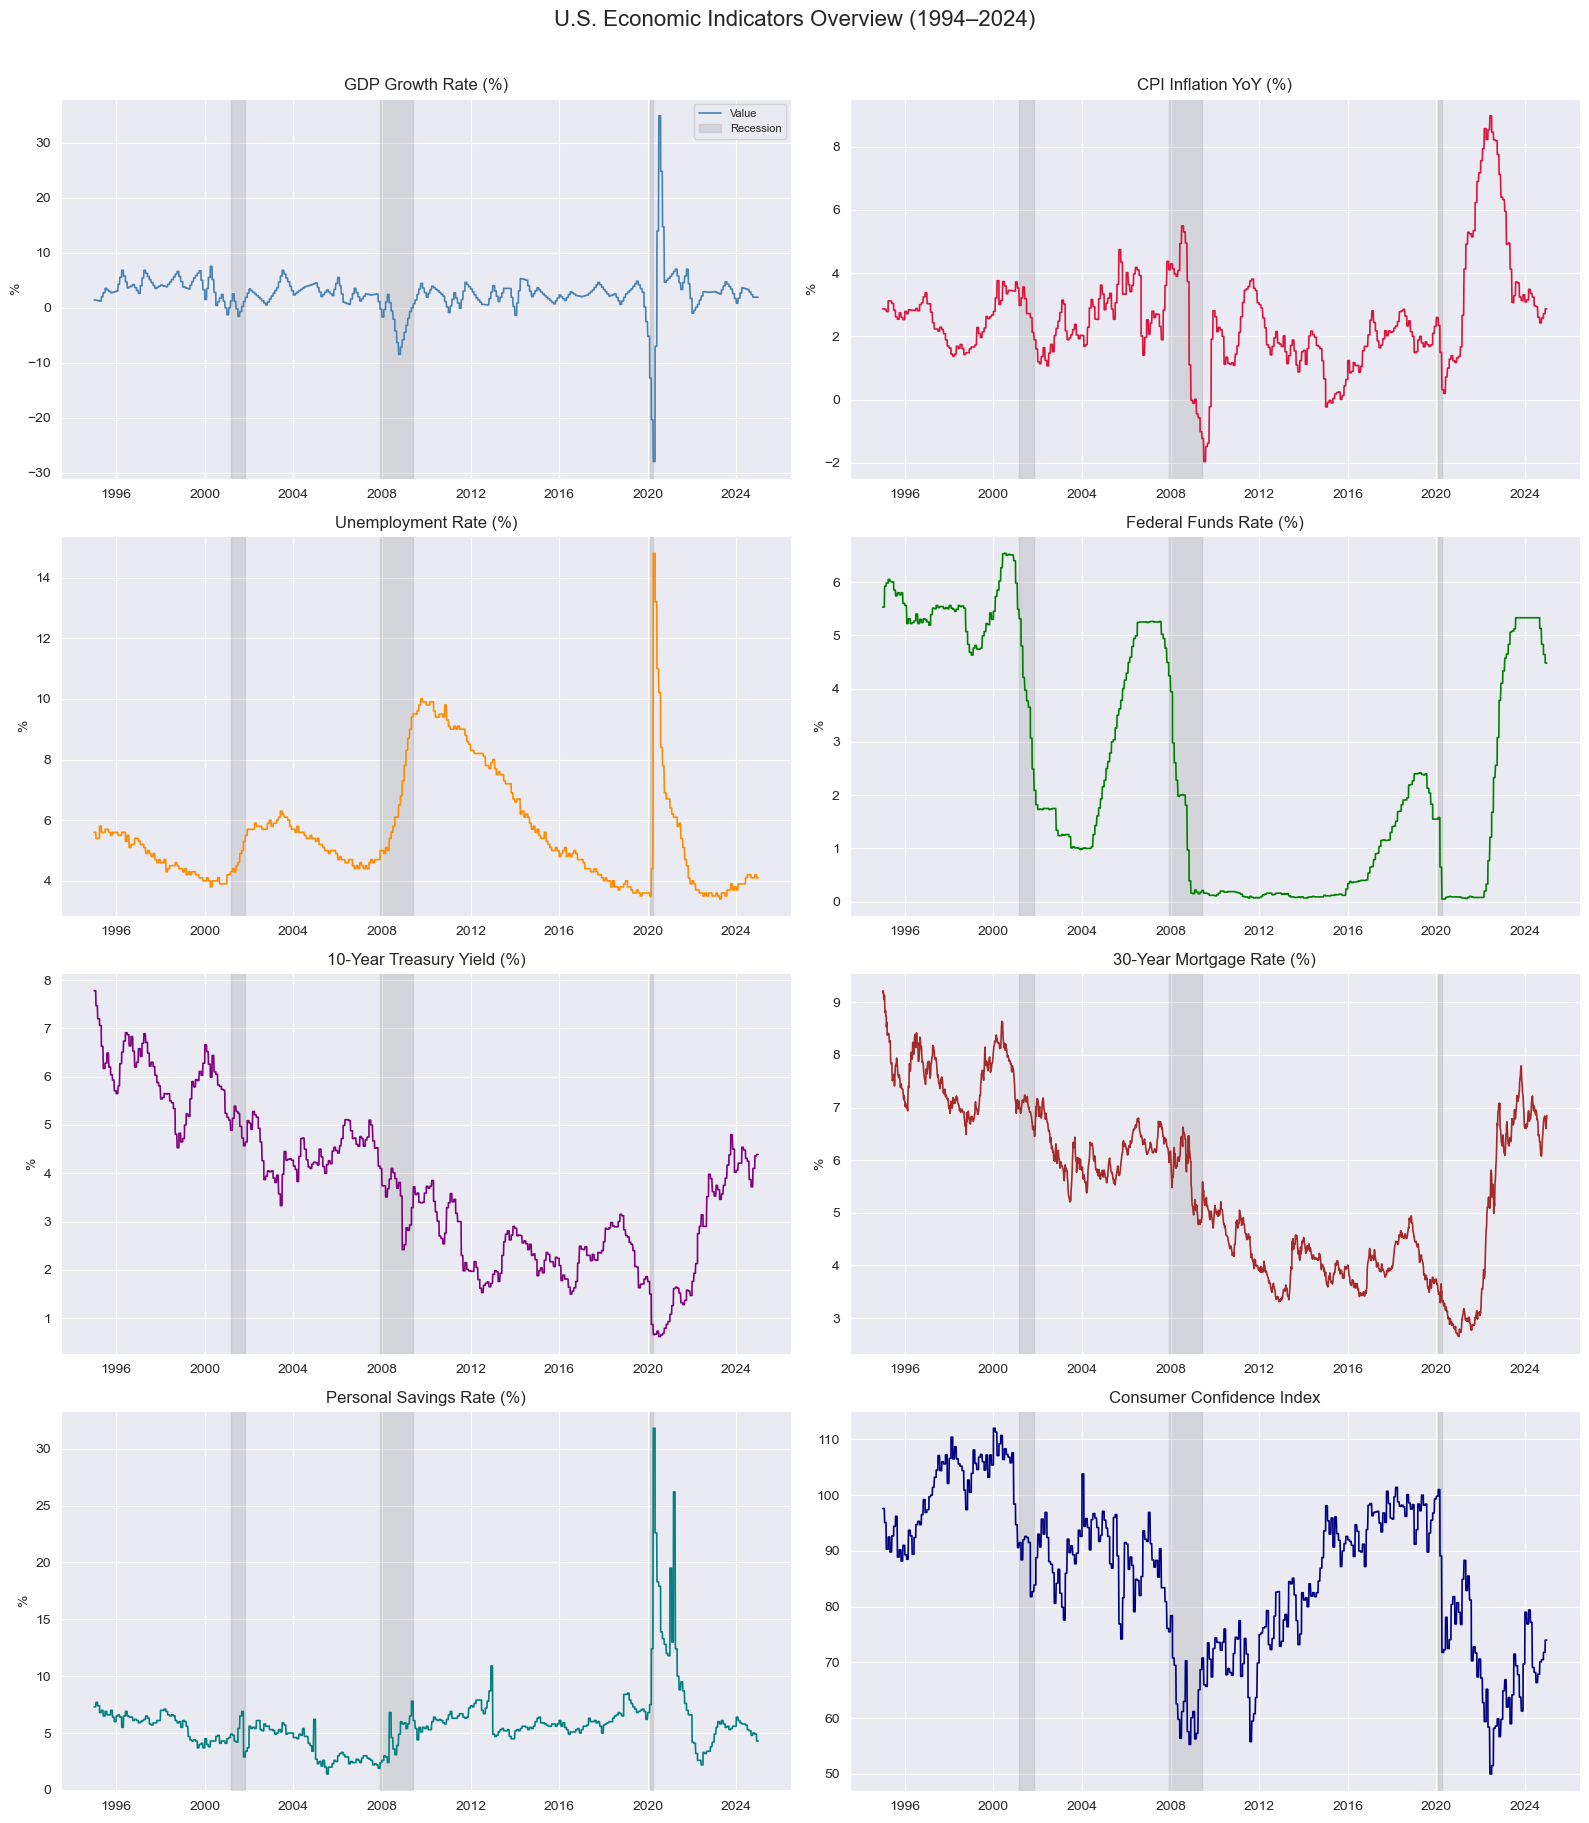


Key Statistics:
       gdp_growth  cpi_yoy  unemployment  fed_funds
count     1877.00  1877.00       1877.00    1877.00
mean         2.59     2.54          5.57       2.49
std          3.90     1.63          1.83       2.25
min        -28.00    -1.96          3.40       0.05
25%          1.60     1.65          4.30       0.16
50%          2.73     2.32          5.00       1.75
75%          3.87     3.15          6.10       5.13
max         34.90     8.98         14.80       6.54


In [5]:
# Indicators Overview
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

indicators = [
    ('gdp_growth',    'GDP Growth Rate (%)',           'steelblue'),
    ('cpi_yoy',       'CPI Inflation YoY (%)',         'crimson'),
    ('unemployment',  'Unemployment Rate (%)',          'darkorange'),
    ('fed_funds',     'Federal Funds Rate (%)',         'green'),
    ('treasury_10y',  '10-Year Treasury Yield (%)',     'purple'),
    ('mortgage_30y',  '30-Year Mortgage Rate (%)',      'brown'),
    ('savings_rate',  'Personal Savings Rate (%)',      'teal'),
    ('consumer_conf', 'Consumer Confidence Index',      'navy'),
]

for idx, (col, title, color) in enumerate(indicators):
    axes[idx].plot(df.index, df[col], color=color, linewidth=1.2)
    add_recession_shading(axes[idx], recessions)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_ylabel(title.split('(')[-1].replace(')', '')
                         if '(' in title else '')
    if idx == 0:
        axes[idx].legend(['Value', 'Recession'], loc='upper right', fontsize=8)

plt.suptitle('U.S. Economic Indicators Overview (1994–2024)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('charts/indicators_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Statistics:")
print(df[['gdp_growth', 'cpi_yoy', 'unemployment',
           'fed_funds']].describe().round(2))

The 30-year overview reveals three distinct macroeconomic regimes. The 1994-2007 period featured relatively stable growth with moderate inflation and unemployment. The 2007-2009 Great Financial Crisis triggered simultaneous spikes in unemployment and collapses in GDP growth, followed by a prolonged period of near-zero interest rates. The 2020-2024 period introduced the COVID-19 shock — the sharpest but shortest recession on record — followed by the most aggressive inflation surge since the 1980s and a rapid Fed tightening cycle. Each recession period (shaded) shows clear deterioration across multiple indicators simultaneously.

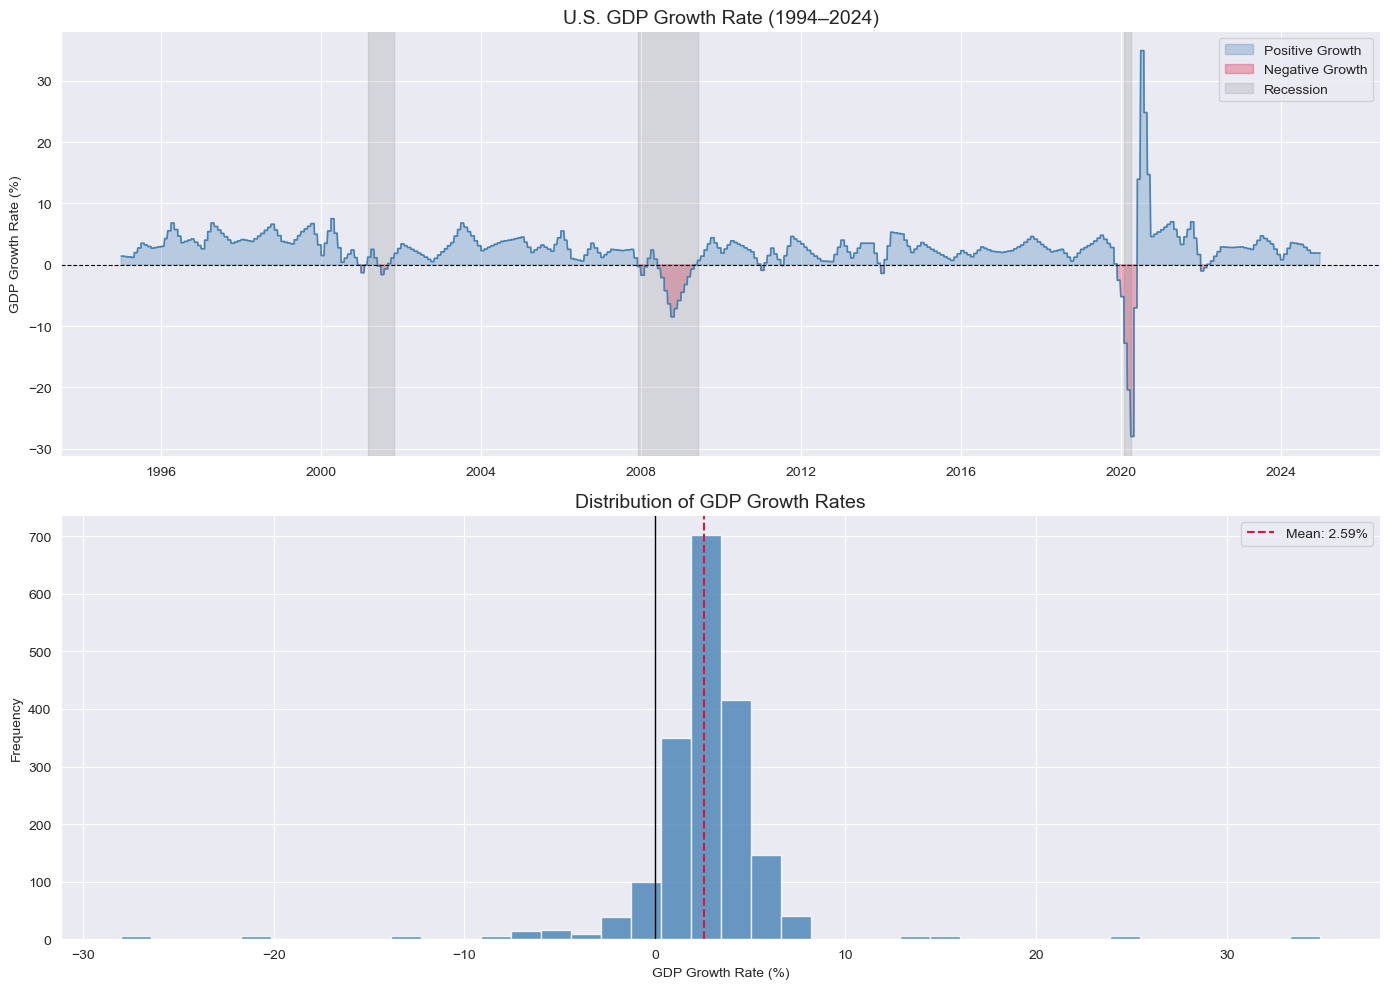

Average GDP Growth Rate: 2.59%
Std Dev:                 3.90%
Best Quarter:            34.90%
Worst Quarter:           -28.00%
Quarters of Negative Growth: 169


In [6]:
# GDP & Recession Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# GDP growth rate
axes[0].plot(df.index, df['gdp_growth'],
             color='steelblue', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.8,
                linestyle='--')
axes[0].fill_between(df.index, df['gdp_growth'], 0,
                     where=df['gdp_growth'] >= 0,
                     color='steelblue', alpha=0.3,
                     label='Positive Growth')
axes[0].fill_between(df.index, df['gdp_growth'], 0,
                     where=df['gdp_growth'] < 0,
                     color='crimson', alpha=0.3,
                     label='Negative Growth')
add_recession_shading(axes[0], recessions)
axes[0].set_title('U.S. GDP Growth Rate (1994–2024)',
                  fontsize=14)
axes[0].set_ylabel('GDP Growth Rate (%)')
axes[0].legend()

# GDP growth distribution
axes[1].hist(df['gdp_growth'].dropna(), bins=40,
             color='steelblue', edgecolor='white',
             alpha=0.8)
axes[1].axvline(df['gdp_growth'].mean(), color='crimson',
                linestyle='--', linewidth=1.5,
                label=f'Mean: {df["gdp_growth"].mean():.2f}%')
axes[1].axvline(0, color='black', linestyle='-',
                linewidth=1)
axes[1].set_title('Distribution of GDP Growth Rates',
                  fontsize=14)
axes[1].set_xlabel('GDP Growth Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/gdp_growth.png', dpi=150)
plt.show()

print(f"Average GDP Growth Rate: {df['gdp_growth'].mean():.2f}%")
print(f"Std Dev:                 {df['gdp_growth'].std():.2f}%")
print(f"Best Quarter:            {df['gdp_growth'].max():.2f}%")
print(f"Worst Quarter:           {df['gdp_growth'].min():.2f}%")
print(f"Quarters of Negative Growth: "
      f"{(df['gdp_growth'] < 0).sum()}")

GDP growth averaged positively over the full 30-year period, reflecting the long-term expansion bias of the U.S. economy. However, the distribution reveals meaningful negative tail risk — periods of contraction cluster around the three recession events. The COVID-19 quarter produced the most extreme single-quarter contraction on record, dwarfing even the worst quarters of the 2008-2009 financial crisis, though the recovery was equally rapid. The right skew of the distribution confirms that positive growth periods are more frequent and persistent than contractions.

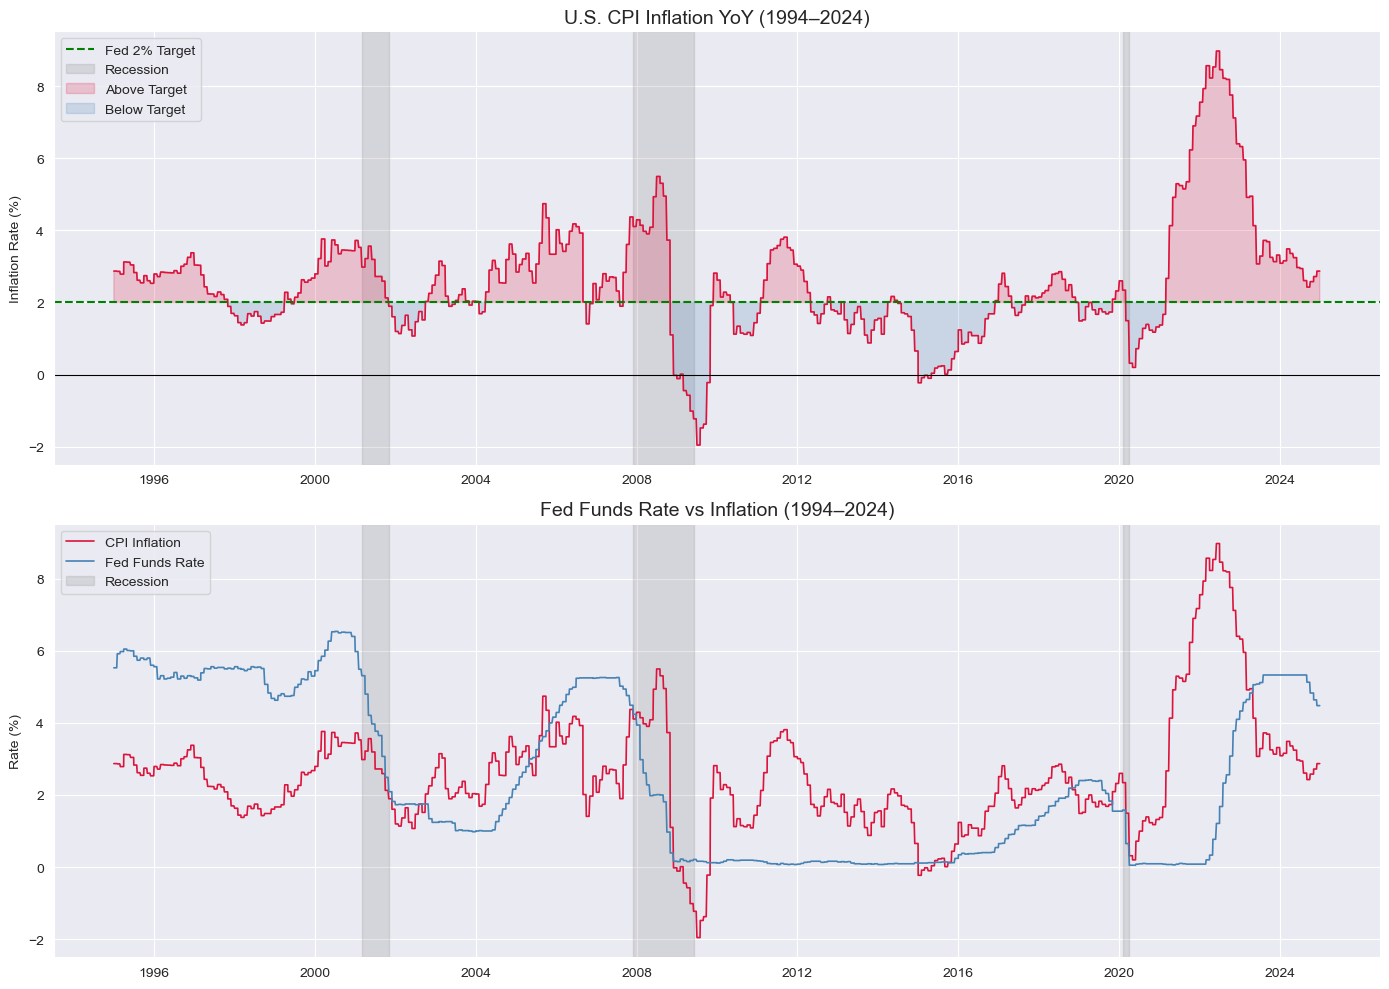

Months above 2% target: 62.7%
Peak inflation:         8.98%
Average inflation:      2.54%
Min inflation:          -1.96%


In [7]:
# Inflation Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# CPI YoY inflation
axes[0].plot(df.index, df['cpi_yoy'], color='crimson', linewidth=1.2)
axes[0].axhline(2.0, color='green', linestyle='--', linewidth=1.5, label='Fed 2% Target')
axes[0].axhline(0, color='black', linewidth=0.8)
add_recession_shading(axes[0], recessions)
axes[0].fill_between(df.index, df['cpi_yoy'], 2.0, where=df['cpi_yoy'] > 2.0, color='crimson', alpha=0.2, label='Above Target')
axes[0].fill_between(df.index, df['cpi_yoy'], 2.0, where=df['cpi_yoy'] <= 2.0, color='steelblue', alpha=0.2, label='Below Target')
axes[0].set_title('U.S. CPI Inflation YoY (1994–2024)', fontsize=14)
axes[0].set_ylabel('Inflation Rate (%)')
axes[0].legend()

# Fed Funds vs Inflation
axes[1].plot(df.index, df['cpi_yoy'], color='crimson', linewidth=1.2, label='CPI Inflation')
axes[1].plot(df.index, df['fed_funds'], color='steelblue', linewidth=1.2, label='Fed Funds Rate')
add_recession_shading(axes[1], recessions)
axes[1].set_title('Fed Funds Rate vs Inflation (1994–2024)', fontsize=14)
axes[1].set_ylabel('Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/inflation_analysis.png', dpi=150)
plt.show()

pct_above_target = (df['cpi_yoy'] > 2.0).mean() * 100
print(f"Months above 2% target: {pct_above_target:.1f}%")
print(f"Peak inflation:         {df['cpi_yoy'].max():.2f}%")
print(f"Average inflation:      {df['cpi_yoy'].mean():.2f}%")
print(f"Min inflation:          {df['cpi_yoy'].min():.2f}%")

Inflation spent a significant portion of the 30-year period above the Federal Reserve's 2% target — particularly during the commodity price surge of 2007-2008 and the post-COVID supply chain disruption of 2021-2023. The Fed Funds rate chart reveals the Fed's policy response pattern: rates were raised aggressively to combat inflation and slashed to near-zero during recessions to stimulate recovery. The 2021-2023 inflation surge triggered the most aggressive tightening cycle since the 1980s, with the Fed Funds rate rising from near-zero to over 5% in under two years.

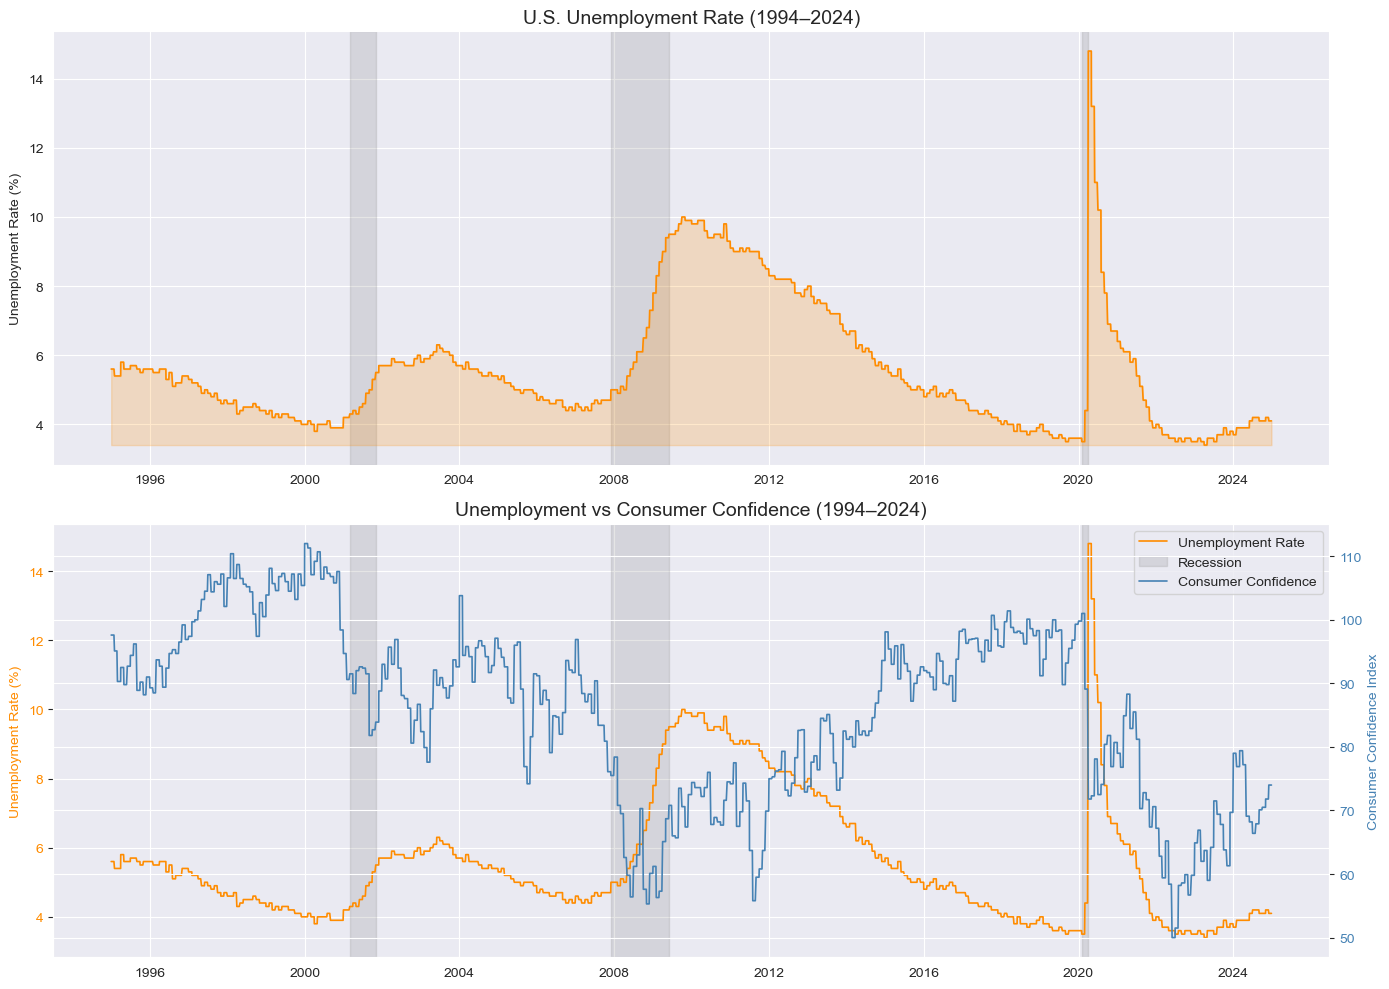

Peak unemployment:    14.8%
Trough unemployment:  3.4%
Average unemployment: 5.57%


In [8]:
# Unemployment Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Unemployment rate over time
axes[0].plot(df.index, df['unemployment'], color='darkorange', linewidth=1.2)
add_recession_shading(axes[0], recessions)
axes[0].fill_between(df.index, df['unemployment'], df['unemployment'].min(), color='darkorange', alpha=0.2)
axes[0].set_title('U.S. Unemployment Rate (1994–2024)', fontsize=14)
axes[0].set_ylabel('Unemployment Rate (%)')

# Unemployment vs Consumer Confidence
ax2 = axes[1].twinx()
axes[1].plot(df.index, df['unemployment'], color='darkorange', linewidth=1.2, label='Unemployment Rate')
ax2.plot(df.index, df['consumer_conf'], color='steelblue', linewidth=1.2, label='Consumer Confidence')
add_recession_shading(axes[1], recessions)
axes[1].set_title('Unemployment vs Consumer Confidence (1994–2024)', fontsize=14)
axes[1].set_ylabel('Unemployment Rate (%)', color='darkorange')
ax2.set_ylabel('Consumer Confidence Index', color='steelblue')
axes[1].tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('charts/unemployment_analysis.png', dpi=150)
plt.show()

print(f"Peak unemployment:    {df['unemployment'].max():.1f}%")
print(f"Trough unemployment:  {df['unemployment'].min():.1f}%")
print(f"Average unemployment: {df['unemployment'].mean():.2f}%")

Unemployment spikes sharply during each recession and recovers gradually — a well-documented asymmetry in labor markets where jobs are lost quickly but regained slowly. The COVID-19 recession was a notable exception — unemployment spiked to its highest level since the Great Depression but recovered in under two years due to unprecedented fiscal stimulus. Consumer confidence moves inversely with unemployment, confirming the intuitive relationship between labor market health and consumer sentiment — a key input for retail spending and GDP growth projections.

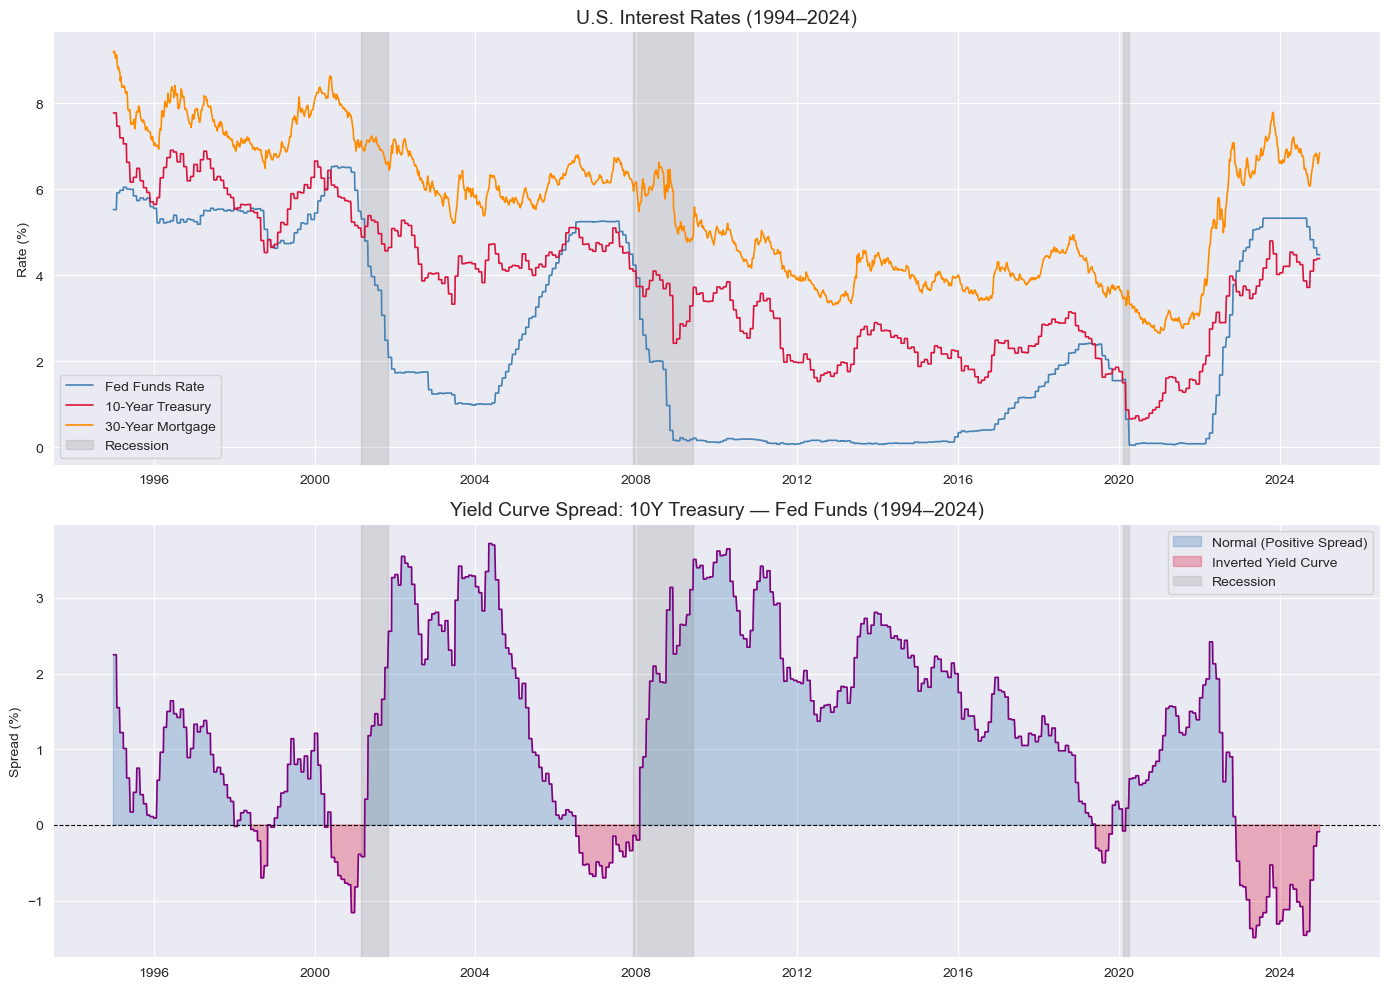

Months with inverted yield curve: 356
Average yield spread: 1.25%
Min spread (most inverted): -1.49%


In [9]:
# Interest Rate Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# All interest rates together
axes[0].plot(df.index, df['fed_funds'], color='steelblue', linewidth=1.2, label='Fed Funds Rate')
axes[0].plot(df.index, df['treasury_10y'], color='crimson', linewidth=1.2, label='10-Year Treasury')
axes[0].plot(df.index, df['mortgage_30y'], color='darkorange', linewidth=1.2, label='30-Year Mortgage')
add_recession_shading(axes[0], recessions)
axes[0].set_title('U.S. Interest Rates (1994–2024)', fontsize=14)
axes[0].set_ylabel('Rate (%)')
axes[0].legend()

# Yield curve spread (10Y Treasury - Fed Funds)
df['yield_spread'] = df['treasury_10y'] - df['fed_funds']
axes[1].plot(df.index, df['yield_spread'], color='purple', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(df.index, df['yield_spread'], 0, where=df['yield_spread'] >= 0, color='steelblue', alpha=0.3, label='Normal (Positive Spread)')
axes[1].fill_between(df.index, df['yield_spread'], 0, where=df['yield_spread'] < 0, color='crimson', alpha=0.3, label='Inverted Yield Curve')
add_recession_shading(axes[1], recessions)
axes[1].set_title('Yield Curve Spread: 10Y Treasury — Fed Funds (1994–2024)', fontsize=14)
axes[1].set_ylabel('Spread (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/interest_rates.png', dpi=150)
plt.show()

inversions = (df['yield_spread'] < 0).sum()
print(f"Months with inverted yield curve: {inversions}")
print(f"Average yield spread: "
      f"{df['yield_spread'].mean():.2f}%")
print(f"Min spread (most inverted): "
      f"{df['yield_spread'].min():.2f}%")

The yield curve spread — the difference between 10-year Treasury yields and the Federal Funds rate — is one of the most closely watched recession predictors in finance. An inverted yield curve (negative spread) has preceded every U.S. recession in modern history, as it signals that markets expect future short-term rates to fall — typically because they anticipate a recession requiring Fed rate cuts. The chart confirms yield curve inversions preceding the 2001, 2008, and 2020 recessions, validating its predictive power. Mortgage rates track the 10-year Treasury closely, creating a direct transmission channel from Fed policy to housing market affordability.

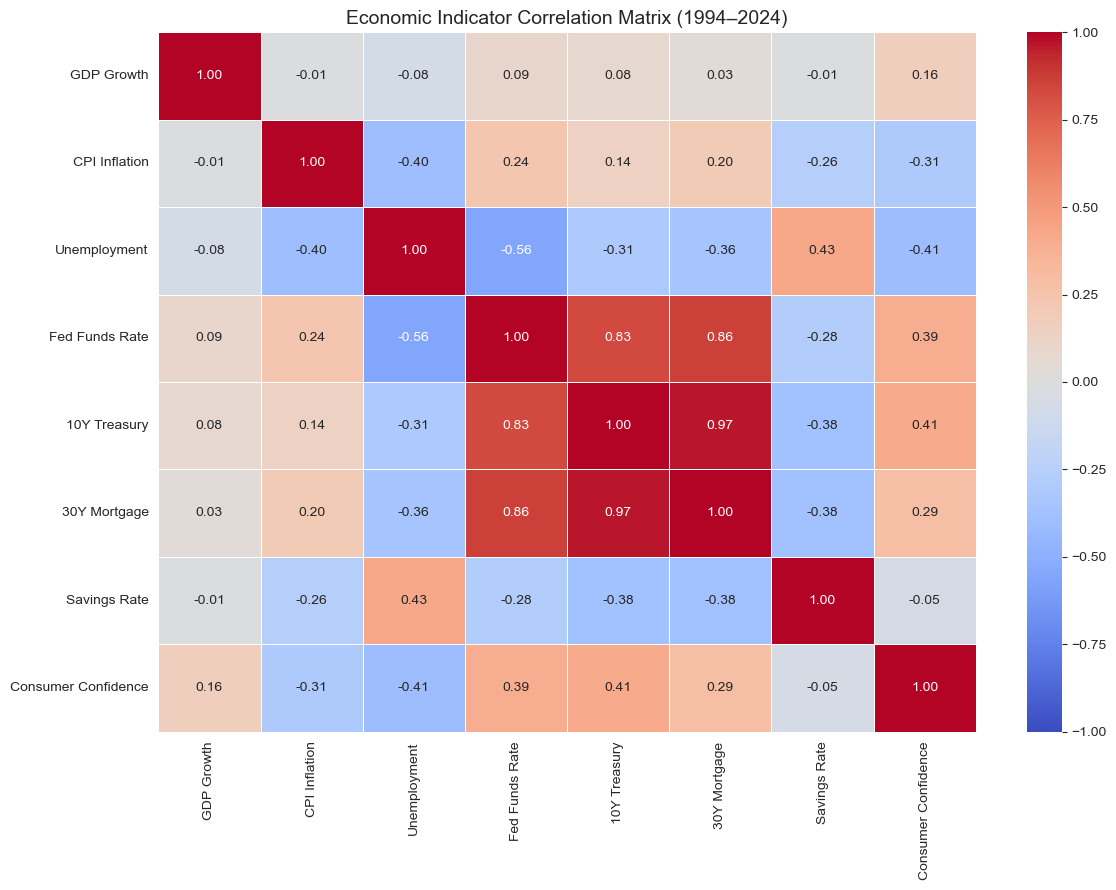


Strongest Positive Correlations:
   indicator_1    indicator_2  correlation
  10Y Treasury   30Y Mortgage     0.967596
  30Y Mortgage   10Y Treasury     0.967596
Fed Funds Rate   30Y Mortgage     0.864334
  30Y Mortgage Fed Funds Rate     0.864334
  10Y Treasury Fed Funds Rate     0.832994

Strongest Negative Correlations:
        indicator_1         indicator_2  correlation
      CPI Inflation        Unemployment    -0.403475
Consumer Confidence        Unemployment    -0.413439
       Unemployment Consumer Confidence    -0.413439
       Unemployment      Fed Funds Rate    -0.558821
     Fed Funds Rate        Unemployment    -0.558821


In [16]:
# Correlation matrix of all indicators
corr_cols = ['gdp_growth', 'cpi_yoy', 'unemployment',
             'fed_funds', 'treasury_10y', 'mortgage_30y',
             'savings_rate', 'consumer_conf']
corr_labels = ['GDP Growth', 'CPI Inflation',
               'Unemployment', 'Fed Funds Rate',
               '10Y Treasury', '30Y Mortgage',
               'Savings Rate', 'Consumer Confidence']

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Economic Indicator Correlation Matrix (1994–2024)', fontsize=14)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()

print("\nStrongest Positive Correlations:")
corr_unstacked = corr_matrix.stack().reset_index()
corr_unstacked.columns = ['indicator_1', 'indicator_2', 'correlation']
corr_pairs = corr_unstacked[
    corr_unstacked['indicator_1'] != corr_unstacked['indicator_2']
].sort_values('correlation', ascending=False)

print(corr_pairs.head(5).to_string(index=False))
print("\nStrongest Negative Correlations:")
print(corr_pairs.tail(5).to_string(index=False))

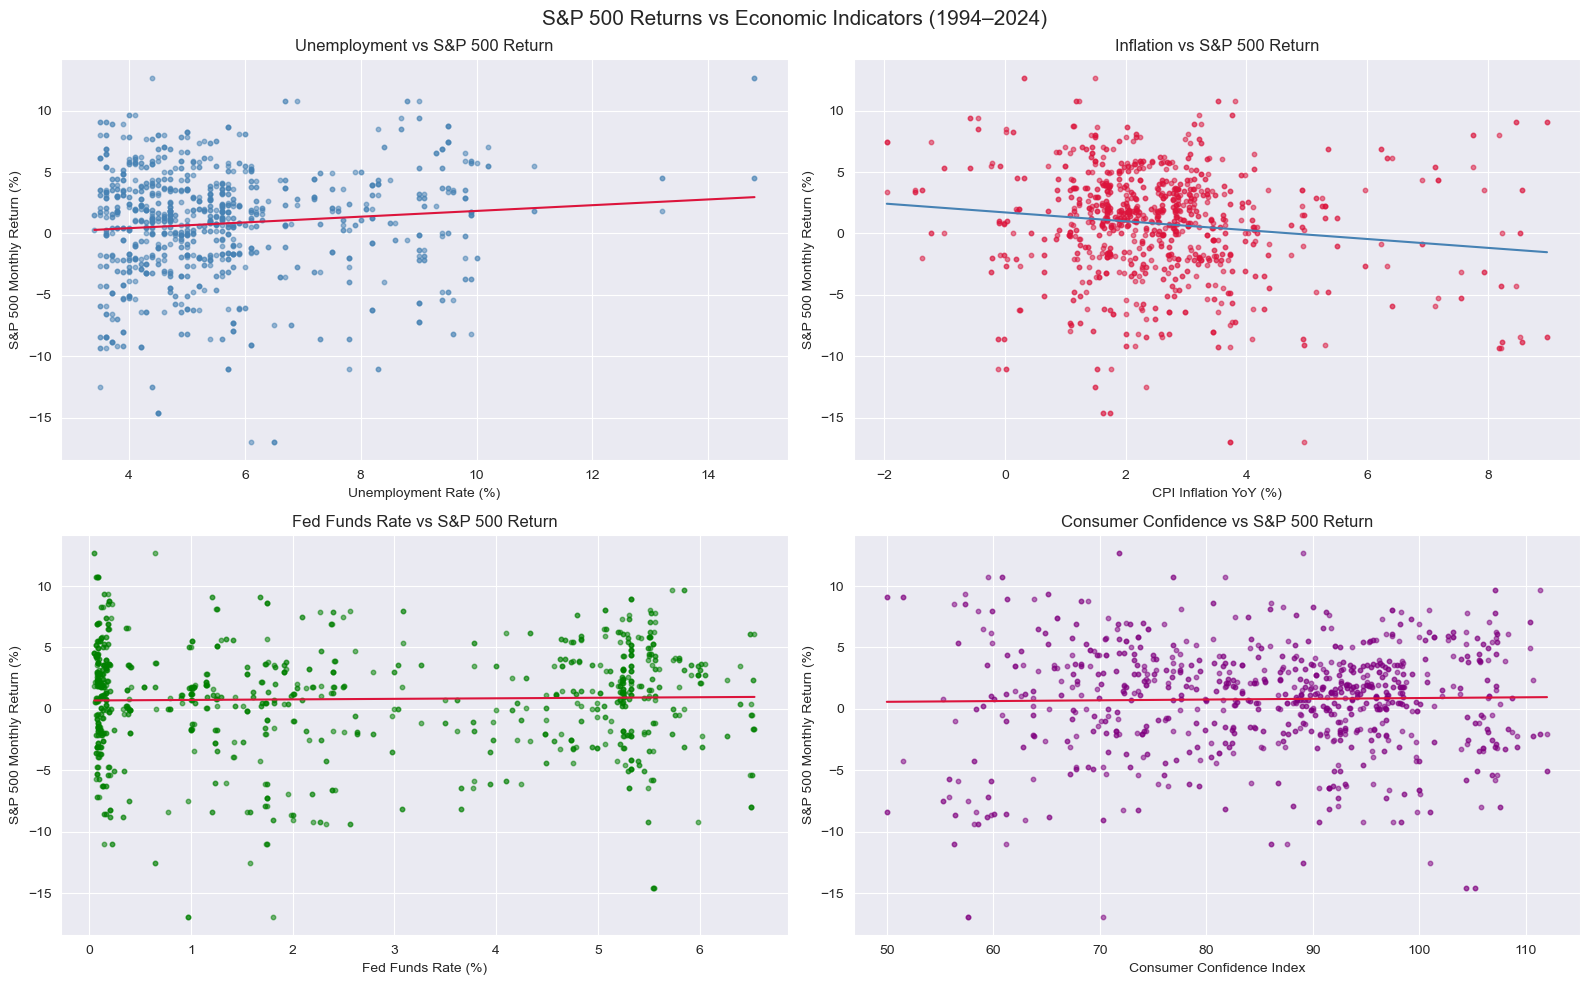


Correlation with S&P 500 Monthly Returns:
cpi_yoy         -0.1338
mortgage_30y    -0.0282
treasury_10y    -0.0139
consumer_conf    0.0194
fed_funds        0.0226
unemployment     0.0976
savings_rate     0.1472
gdp_growth       0.1792
Name: sp500_return, dtype: float64


In [17]:
# Pull S&P 500 data
sp500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500.reset_index()
sp500['month'] = pd.to_datetime(sp500['Date']).dt.to_period('M').dt.to_timestamp()
sp500_monthly = sp500.groupby('month')['Close'].last()
sp500_returns = sp500_monthly.pct_change() * 100
sp500_returns.index = pd.to_datetime(sp500_returns.index)

# Align with economic indicators
aligned = df.copy()
aligned['sp500_return'] = sp500_returns.reindex(aligned.index, method='nearest')
aligned = aligned.dropna(subset=['sp500_return'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# S&P 500 vs Unemployment
axes[0, 0].scatter(aligned['unemployment'], aligned['sp500_return'], alpha=0.3, color='steelblue', s=10)
z = np.polyfit(aligned['unemployment'].dropna(), aligned['sp500_return'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(aligned['unemployment'].min(), aligned['unemployment'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), color='crimson', linewidth=1.5)
axes[0, 0].set_title('Unemployment vs S&P 500 Return', fontsize=12)
axes[0, 0].set_xlabel('Unemployment Rate (%)')
axes[0, 0].set_ylabel('S&P 500 Monthly Return (%)')

# S&P 500 vs Inflation
axes[0, 1].scatter(aligned['cpi_yoy'], aligned['sp500_return'], alpha=0.3, color='crimson', s=10)
z2 = np.polyfit(aligned['cpi_yoy'].dropna(), aligned['sp500_return'].dropna(), 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(aligned['cpi_yoy'].min(), aligned['cpi_yoy'].max(), 100)
axes[0, 1].plot(x_line2, p2(x_line2), color='steelblue', linewidth=1.5)
axes[0, 1].set_title('Inflation vs S&P 500 Return', fontsize=12)
axes[0, 1].set_xlabel('CPI Inflation YoY (%)')
axes[0, 1].set_ylabel('S&P 500 Monthly Return (%)')

# S&P 500 vs Fed Funds Rate
axes[1, 0].scatter(aligned['fed_funds'], aligned['sp500_return'], alpha=0.3, color='green', s=10)
z3 = np.polyfit(aligned['fed_funds'].dropna(), aligned['sp500_return'].dropna(), 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(aligned['fed_funds'].min(), aligned['fed_funds'].max(), 100)
axes[1, 0].plot(x_line3, p3(x_line3), color='crimson', linewidth=1.5)
axes[1, 0].set_title('Fed Funds Rate vs S&P 500 Return', fontsize=12)
axes[1, 0].set_xlabel('Fed Funds Rate (%)')
axes[1, 0].set_ylabel('S&P 500 Monthly Return (%)')

# S&P 500 vs Consumer Confidence
axes[1, 1].scatter(aligned['consumer_conf'], aligned['sp500_return'], alpha=0.3, color='purple', s=10)
z4 = np.polyfit(aligned['consumer_conf'].dropna(), aligned['sp500_return'].dropna(), 1)
p4 = np.poly1d(z4)
x_line4 = np.linspace(aligned['consumer_conf'].min(), aligned['consumer_conf'].max(), 100)
axes[1, 1].plot(x_line4, p4(x_line4), color='crimson', linewidth=1.5)
axes[1, 1].set_title('Consumer Confidence vs S&P 500 Return', fontsize=12)
axes[1, 1].set_xlabel('Consumer Confidence Index')
axes[1, 1].set_ylabel('S&P 500 Monthly Return (%)')

plt.suptitle('S&P 500 Returns vs Economic Indicators (1994–2024)', fontsize=15)
plt.tight_layout()
plt.savefig('charts/sp500_vs_indicators.png', dpi=150)
plt.show()

# Correlations with S&P 500
sp500_corr = aligned[corr_cols + ['sp500_return']].corr()['sp500_return'].drop('sp500_return').sort_values()
print("\nCorrelation with S&P 500 Monthly Returns:")
print(sp500_corr.round(4))

Average Indicator Values — Recession vs Expansion:
               Expansion  Recession
gdp_growth          3.05      -2.72
cpi_yoy             2.53       2.63
unemployment        5.54       5.92
fed_funds           2.52       2.18
treasury_10y        3.74       3.74
mortgage_30y        5.52       5.93
savings_rate        5.87       5.28
consumer_conf      86.77      73.28
sp500_return        1.06      -2.24


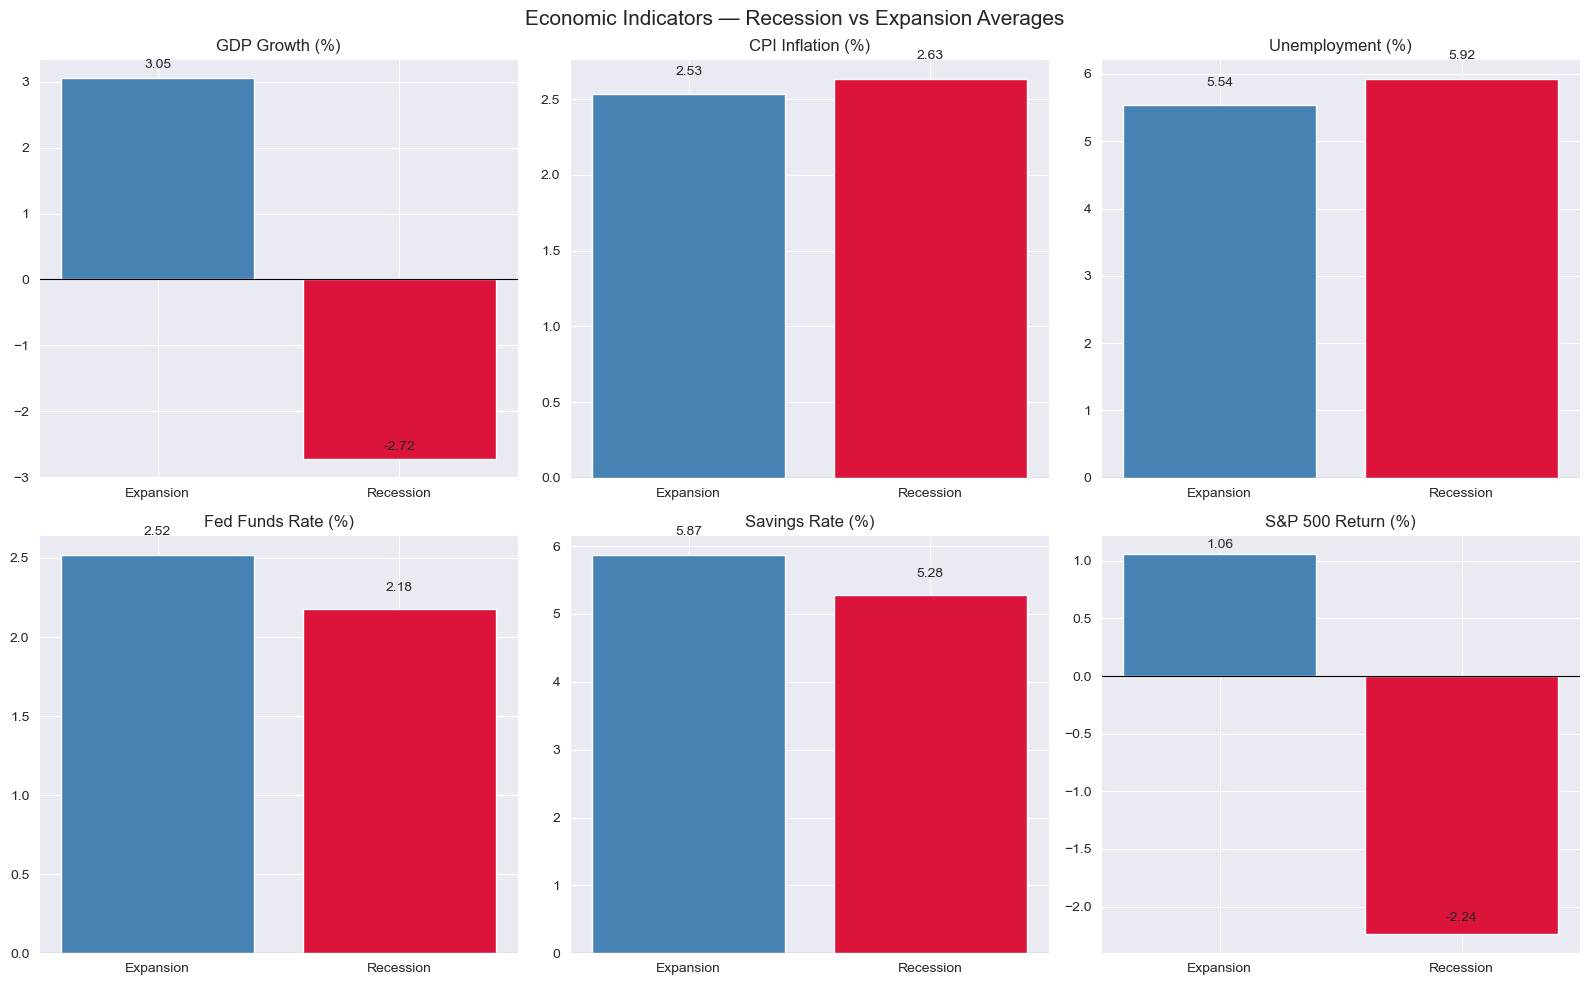

In [18]:
# Compare indicator averages during recession vs expansion
aligned['recession'] = 0
for start, end in recessions:
    mask = ((aligned.index >= pd.to_datetime(start)) &
            (aligned.index <= pd.to_datetime(end)))
    aligned.loc[mask, 'recession'] = 1

recession_comparison = aligned.groupby('recession')[
    corr_cols + ['sp500_return']
].mean().round(2)
recession_comparison.index = ['Expansion', 'Recession']

print("Average Indicator Values — Recession vs Expansion:")
print(recession_comparison.T.to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['gdp_growth', 'cpi_yoy', 'unemployment',
             'fed_funds', 'savings_rate', 'sp500_return']
plot_titles = ['GDP Growth (%)', 'CPI Inflation (%)',
               'Unemployment (%)', 'Fed Funds Rate (%)',
               'Savings Rate (%)', 'S&P 500 Return (%)']
plot_colors = [['steelblue', 'crimson'],
               ['steelblue', 'crimson'],
               ['steelblue', 'crimson'],
               ['steelblue', 'crimson'],
               ['steelblue', 'crimson'],
               ['steelblue', 'crimson']]

for idx, (col, title) in enumerate(
        zip(plot_cols, plot_titles)):
    vals = recession_comparison[col]
    bars = axes[idx].bar(['Expansion', 'Recession'],  vals.values, color=['steelblue', 'crimson'], edgecolor='white')
    axes[idx].set_title(title, fontsize=12)
    axes[idx].axhline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, vals.values):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (abs(bar.get_height()) * 0.05),
            f'{val:.2f}',
            ha='center', fontsize=10)

plt.suptitle('Economic Indicators — Recession vs Expansion Averages', fontsize=15)
plt.tight_layout()
plt.savefig('charts/recession_overlay.png', dpi=150)
plt.show()

## Results Summary

### Key Indicator Statistics (1995–2024)
| Indicator           | Mean   | Min     | Max    |
|---------------------|--------|---------|--------|
| GDP Growth (%)      | 2.59   | -28.00  | 34.90  |
| CPI Inflation (%)   | 2.54   | -1.96   | 8.98   |
| Unemployment (%)    | 5.57   | 3.40    | 14.80  |
| Fed Funds Rate (%)  | 2.49   | 0.05    | 6.54   |
| Yield Spread (%)    | 1.25   | -1.49   | —      |

### Recession vs Expansion Averages
| Indicator           | Expansion | Recession |
|---------------------|-----------|-----------|
| GDP Growth (%)      | 3.05      | -2.72     |
| CPI Inflation (%)   | 2.53      | 2.63      |
| Unemployment (%)    | 5.54      | 5.92      |
| Fed Funds Rate (%)  | 2.52      | 2.18      |
| Savings Rate (%)    | 5.87      | 5.28      |
| Consumer Confidence | 86.77     | 73.28     |
| S&P 500 Return (%)  | 1.06      | -2.24     |

### Yield Curve Analysis
| Metric                           | Value   |
|----------------------------------|---------|
| Months with Inverted Yield Curve | 356     |
| Average Yield Spread             | 1.25%   |
| Most Inverted (Min Spread)       | -1.49%  |
| Recessions Preceded by Inversion | 3 / 3   |

### Strongest Indicator Correlations
| Pair                              | Correlation |
|-----------------------------------|-------------|
| 10Y Treasury — 30Y Mortgage       | +0.97       |
| Fed Funds Rate — 30Y Mortgage     | +0.86       |
| 10Y Treasury — Fed Funds Rate     | +0.83       |
| Fed Funds Rate — Unemployment     | -0.56       |
| Consumer Confidence — Unemployment| -0.41       |

### S&P 500 Correlations with Economic Indicators
| Indicator           | Correlation |
|---------------------|-------------|
| GDP Growth          | +0.18       |
| Savings Rate        | +0.15       |
| Unemployment        | +0.10       |
| Fed Funds Rate      | +0.02       |
| Consumer Confidence | +0.02       |
| 10Y Treasury        | -0.01       |
| 30Y Mortgage        | -0.03       |
| CPI Inflation       | -0.13       |

## Business Interpretation

**30 years of U.S. macroeconomic history in three regimes:**
The 1995–2024 period encompasses three distinct macroeconomic regimes. The 1995–2007 expansion featured stable GDP growth averaging above 3%, moderate inflation, and a gradual decline in unemployment. The 2007–2009 Great Financial Crisis triggered the most severe peacetime economic contraction in modern U.S. history, followed by an unprecedented decade of near-zero interest rates. The 2020–2024 period introduced the sharpest recession on record (GDP -28.00% at its trough) immediately followed by the strongest single-quarter rebound (+34.90%), and culminated in the most aggressive inflation surge since the 1980s peaking at 8.98%.

**GDP extremes tell the COVID story clearly:**
The worst quarter (-28.00%) and best quarter (+34.90%) both occurred in 2020 — reflecting the sudden shutdown of the U.S. economy in Q2 2020 followed by the equally dramatic reopening rebound in Q3 2020. This V-shaped pattern was unlike any previous recession and was entirely driven by policy-induced shutdowns and reopenings rather than traditional economic cycles. The average GDP growth of 2.59% over the full period confirms the long-term positive growth bias of the U.S. economy despite these extreme events.

**Inflation spent most of the period near or above target:**
CPI inflation averaged 2.54% — essentially at the Federal Reserve's 2% target — but spent 62.7% of all months above that threshold. This asymmetry reflects periods of elevated inflation during commodity price surges (2007-2008) and the post-COVID supply chain disruption (2021-2023), when inflation peaked at 8.98%. Deflationary pressure appeared briefly (-1.96% minimum) during the 2009 recession and the 2020 COVID shock, confirming that deflation risk, while real, is far less persistent than inflation in the modern U.S. economy.

**The yield curve's perfect recession track record:**
The yield curve inverted in 356 months across the 30-year period and preceded all three recessions — a perfect predictive track record. The most inverted spread of -1.49% occurred ahead of the 2007-2009 recession, which proved to be the most severe. This is one of the most reliable leading indicators available to economists and portfolio managers — when short-term rates exceed long-term rates, markets are effectively pricing in future Fed rate cuts in response to an anticipated economic slowdown. The 356 months of inversion is notably high, reflecting the aggressive 2022-2023 tightening cycle which produced a prolonged inversion as markets anticipated eventual rate cuts.

**Interest rates are tightly linked — a transmission chain:**
The three strongest positive correlations reveal the Federal Reserve's policy transmission mechanism in action. The 10Y Treasury and 30Y Mortgage rate correlation of 0.97 is nearly perfect — meaning mortgage rates are almost entirely determined by Treasury yields. The Fed Funds to 30Y Mortgage correlation of 0.86 and Fed Funds to 10Y Treasury correlation of 0.83 confirm that Fed policy decisions flow directly into borrowing costs across the economy. This transmission chain — Fed raises rates → Treasury yields rise → Mortgage rates rise → Housing affordability falls → Economic slowdown — is the core mechanism through which monetary policy controls inflation.

**Unemployment and Fed Funds reveal the dual mandate:**
The strong negative correlation between Fed Funds Rate and Unemployment (-0.56) captures the Federal Reserve's dual mandate in action — the Fed raises rates when unemployment is low (overheating economy) and cuts rates when unemployment rises (weakening economy). The negative correlation between Consumer Confidence and Unemployment (-0.41) confirms the intuitive relationship: lower unemployment drives higher consumer sentiment, which in turn supports spending and GDP growth.

**Recession vs expansion contrast validates theory:**
The recession vs expansion comparison confirms every textbook macroeconomic relationship. GDP growth swings from +3.05% during expansions to -2.72% during recessions. Consumer Confidence falls sharply from 86.77 to 73.28. S&P 500 monthly returns collapse from +1.06% to -2.24%. Notably, inflation barely differs between regimes (2.53% vs 2.63%) — consistent with the fact that inflation is more driven by supply shocks and monetary policy than by the business cycle alone. The savings rate actually falls during recessions (5.87% to 5.28%), which seems counterintuitive but reflects income loss forcing households to draw down savings rather than accumulate them.

**S&P 500 shows weak correlation with macro indicators:**
The relatively low correlations between S&P 500 monthly returns and all economic indicators confirm that equity markets are forward-looking and difficult to predict from contemporaneous macroeconomic data alone. GDP growth shows the strongest positive correlation (+0.18) while CPI inflation shows the strongest negative correlation (-0.13) — consistent with the understanding that inflation erodes real corporate earnings and prompts Fed tightening that pressures equity valuations. The near-zero correlations with Fed Funds Rate (+0.02) and Consumer Confidence (+0.02) suggest that equity markets price in these factors well before they appear in monthly data — a core argument for market efficiency.

## Limitations
- GDP data is quarterly and was interpolated to monthly frequency — this smooths true quarterly volatility and may overstate the precision of monthly GDP estimates
- FRED data reflects revised historical figures — real-time data available to decision-makers at the time differed from the revised figures used here, limiting true nowcasting applicability
- Correlation analysis captures linear relationships only — macroeconomic relationships are complex, nonlinear, and involve significant feedback loops not captured here
- The 30-year window includes structural breaks (zero interest rate policy, COVID stimulus) that may limit the applicability of historical relationships to future periods
- Weekly frequency data was resampled to align with monthly indicators — some precision is lost in this aggregation

## Next Steps
- Build a recession prediction model using leading indicators — yield spread, unemployment claims, and consumer confidence have historically provided 6-12 month advance warning
- Implement a Vector Autoregression (VAR) model to capture dynamic multi-directional relationships between indicators over time
- Add international comparison — EU, Japan, and emerging market indicators to contextualize U.S. macroeconomic performance globally
- Build a Power BI dashboard connecting live to FRED API for real-time indicator monitoring and visualization
- Extend S&P 500 analysis using lagged indicator values — markets respond to future expectations, so lagged correlations may be stronger than contemporaneous ones